<a href="https://colab.research.google.com/github/javmencia/RelativeBelief/blob/Round2/LinReg6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from scipy.stats import binom, beta
from scipy.special import logsumexp
import numpy as np
from scipy.stats import norm, invgamma, multivariate_normal
import matplotlib.pyplot as plt

# Linear Regression

## Hypothesis

## Bias Against

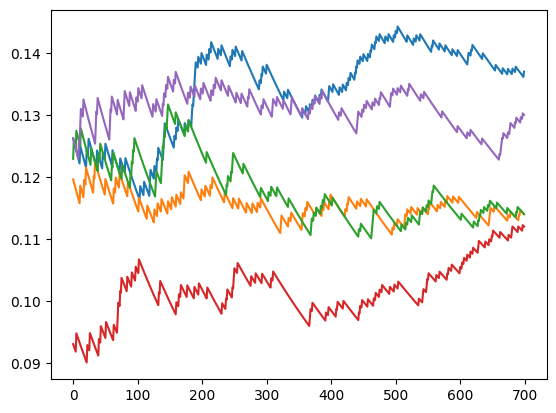

In [2]:
import numpy as np
from scipy.stats import multivariate_normal, invgamma
from scipy.special import logsumexp

def hypothesis_bias_against_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    mu_prior_mean,
    mu_prior_sigma,
    sigma_prior_alpha,
    sigma_prior_beta,
    cumulative=True,
    n_datasets=1000,
    n_marginal=1000
):
    """
    Calculate the bias against for the hypothesis problem using the sufficient statistic approach for the linear regression model.

    Parameters:
    - n_sample (int): Sample size.
    - beta0 (np.ndarray): Hypothesized beta coefficients (p, ).
    - X (np.ndarray): Design matrix (n_sample, p).
    - sigma0 (float): Hypothesized noise variance.
    - mu_prior_mean (np.ndarray): Mean of the prior distribution for beta (p, ).
    - mu_prior_sigma (np.ndarray): Covariance matrix of the prior distribution for beta (p, p).
    - sigma_prior_alpha (float): Alpha parameter of the Inverse-Gamma prior for sigma^2.
    - sigma_prior_beta (float): Beta (scale) parameter of the Inverse-Gamma prior for sigma^2.
    - cumulative (bool): Whether to return cumulative bias values.
    - n_datasets (int): Number of datasets to simulate.
    - n_marginal (int): Number of samples to estimate the marginal likelihood.

    Returns:
    - float or np.ndarray: Final bias against estimate or cumulative bias against values.
    """

    # Step 1: Generate synthetic datasets under the hypothesis
    p = X.shape[1]  # Number of predictors
    y = np.dot(X, beta0) + np.random.normal(0, np.sqrt(sigma0), size=(n_datasets, n_sample))

    # Step 2: Compute the log-likelihood of y under the hypothesis
    log_likelihood = multivariate_normal.logpdf(
        y, mean=np.dot(X, beta0), cov=sigma0 * np.eye(n_sample)
    )  # Shape: (n_datasets,)

    # Step 3: Sample beta and sigma^2 from their respective priors
    beta_samples = multivariate_normal.rvs(mean=mu_prior_mean, cov=mu_prior_sigma, size=n_marginal)
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=n_marginal)

    # Step 4: Compute the marginal likelihood p(y | X) via Monte Carlo integration
    log_likelihoods = np.zeros((n_datasets, n_marginal))

    for i in range(n_marginal):
        mu_samples = np.dot(X, beta_samples[i])
        log_likelihoods[:, i] = multivariate_normal.logpdf(
            y, mean=mu_samples, cov=sigma_samples[i] * np.eye(n_sample)
        )

    # Compute log marginal likelihood for each y using log-sum-exp trick
    log_marginal_likelihood = logsumexp(log_likelihoods, axis=1) - np.log(n_marginal)

    # Step 5: Calculate bias against hypothesis
    bias_against = (log_likelihood - log_marginal_likelihood) <= 0

    # Compute cumulative bias against if requested
    bias_against_cumsum = np.cumsum(bias_against) / np.arange(1, n_datasets + 1)

    if cumulative:
        return bias_against_cumsum[300:]
    else:
        return bias_against_cumsum[-1]


import matplotlib.pyplot as plt
# Parameters
# Define prior parameters
mu_prior_mean = [1, 2]
mu_prior_sigma = 1
sigma_prior_alpha = 3
sigma_prior_beta = 2

n=10; p = 2
X = np.ones((n, p))
X[:int(n/2),0] = 0
X[0:-1:2,1] = 0

# Ground truth parameters
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1
mu0 = np.dot(X, beta0)

loops = 5
for i in range(loops):
    # Calculate bias against
    bias_against = hypothesis_bias_against_lin_reg(
        n,
        beta0,
        X,
        sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha = sigma_prior_alpha,
        sigma_prior_beta = sigma_prior_beta,
        cumulative = True,
        n_datasets=1000,
        n_marginal=1000
        )
    plt.plot(bias_against)

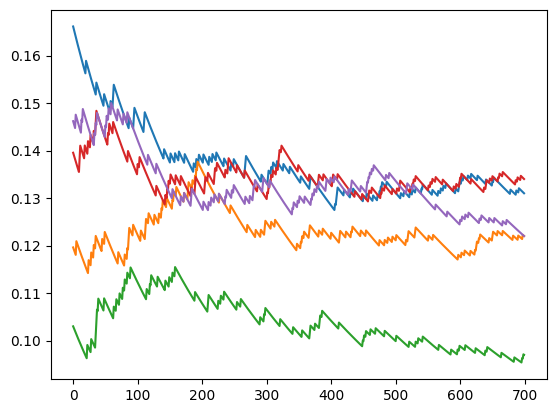

In [ ]:
import numpy as np
from scipy.stats import multivariate_normal, invgamma
from scipy.special import logsumexp
import matplotlib.pyplot as plt

def hypothesis_bias_against_lin_reg(
    n_sample,
    X,
    mu_prior_mean,
    mu_prior_sigma,
    sigma_prior_alpha,
    sigma_prior_beta,
    cumulative=True,
    n_datasets=1000,
    n_marginal=1000
):
    """
    Calculate the bias against a hypothesis using the sufficient statistic approach for the linear regression model.

    Parameters:
    - n_sample (int): Sample size.
    - beta0 (np.ndarray): Hypothesized beta coefficients (p, ).
    - X (np.ndarray): Design matrix (n_sample, p).
    - sigma0 (float): Hypothesized noise variance.
    - mu_prior_mean (np.ndarray): Mean of the prior distribution for beta (p, ).
    - mu_prior_sigma (np.ndarray): Covariance matrix of the prior distribution for beta (p, p).
    - sigma_prior_alpha (float): Alpha parameter of the Inverse-Gamma prior for sigma^2.
    - sigma_prior_beta (float): Beta (scale) parameter of the Inverse-Gamma prior for sigma^2.
    - cumulative (bool): Whether to return cumulative bias values.
    - n_datasets (int): Number of datasets to simulate.
    - n_marginal (int): Number of samples to estimate the marginal likelihood.

    Returns:
    - float or np.ndarray: Final bias against estimate or cumulative bias against values.
    """


    # Step 1: Sample p₀ from the prior distribution
    beta_samples = multivariate_normal.rvs(mean=mu_prior_mean, cov=mu_prior_sigma, size=n_marginal)
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=n_marginal)

    # Step 2: Generate x from p(x | p₀)
    y = np.dot(X, beta_samples) + np.random.normal(0, np.sqrt(sigma_samples), size=(n_datasets, n_sample))

    # Step 3: Compute log-likelihoods of x under p₀
    log_likelihood = multivariate_normal.logpdf(
        y, mean=np.dot(X, beta0), cov=sigma0 * np.eye(n_sample)
    )  # Shape: (n_datasets,)

    # Step 4: Sample p_j from the prior distribution
    p_j_samples = np.random.beta(prior_alpha, prior_beta, size=n_marginal)
    beta_j_samples = multivariate_normal.rvs(mean=mu_prior_mean, cov=mu_prior_sigma, size=n_marginal)
    sigma_j_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=n_marginal)

    # Step 5: Compute the marginal likelihood p(x) via Monte Carlo integration
    # Compute log p(x | p_j) for each p_j and x
    # Shape: (n_datasets, n_marginal)
    log_likelihoods = np.zeros((n_datasets, n_marginal))

    for i in range(n_marginal):
        mu_samples = np.dot(X, beta_j_samples[i])
        log_likelihoods[:, i] = multivariate_normal.logpdf(
            y, mean=mu_samples, cov=sigma_j_samples[i] * np.eye(n_sample)
        )


    # Compute log marginal likelihood for each x using log-sum-exp trick
    # log p(x) = log(1/n_marginal * sum_{j} exp(log p(x | p_j)))
    log_marginal_likelihood = logsumexp(log_likelihoods, axis=1) - np.log(n_marginal)

    # Step 6: Compute the bias against
    bias_against = (log_likelihood - log_marginal_likelihood) <= 0

    # Compute cumulative bias against if requested
    bias_against_cumsum = np.cumsum(bias_against) / np.arange(1, n_datasets + 1)

    if cumulative:
        return bias_against_cumsum[300:]
    else:
        return bias_against_cumsum[-1]




# Parameters
# Define prior parameters
mu_prior_mean = [1, 2]
mu_prior_sigma = 1
sigma_prior_alpha = 3
sigma_prior_beta = 2

n=10; p = 2
X = np.ones((n, p))
X[:int(n/2),0] = 0
X[0:-1:2,1] = 0


loops = 5
for i in range(loops):
    # Calculate bias against
    bias_against = hypothesis_bias_against_lin_reg(
        n,
        beta0,
        X,
        sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha = sigma_prior_alpha,
        sigma_prior_beta = sigma_prior_beta,
        cumulative = True,
        n_datasets=1000,
        n_marginal=1000
        )
    plt.plot(bias_against)

### Sample Size

[5, 15, 25, 35, 45]


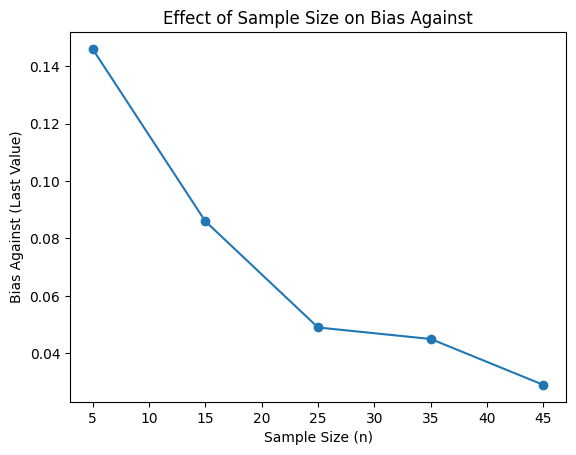

In [ ]:

# Parameters
mu_prior_mean = [1, 2]
mu_prior_sigma = 1
sigma_prior_alpha = 3
sigma_prior_beta = 2
p = 2
delta = 0.05
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Define n values
n_values = list(range(5, 50 + 1, 10))
bias_against_last_values = []
print(n_values)
for n in n_values:
    # Create X matrix with size (n, p)
    X = np.ones((n, p))
    X[:int(n/2), 0] = 0
    X[0:-1:2, 1] = 0
    bias_against_last = hypothesis_bias_against_lin_reg(
        n_sample=n,
        beta0=beta0,
        X=X,
        sigma0=sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        cumulative=False,
        n_datasets=1000
    )
    bias_against_last_values.append(bias_against_last)

# Plotting
plt.plot(n_values, bias_against_last_values, marker='o')
plt.xlabel("Sample Size (n)")
plt.ylabel("Bias Against (Last Value)")
plt.title("Effect of Sample Size on Bias Against")
plt.show()


[5, 15, 25, 35, 45]


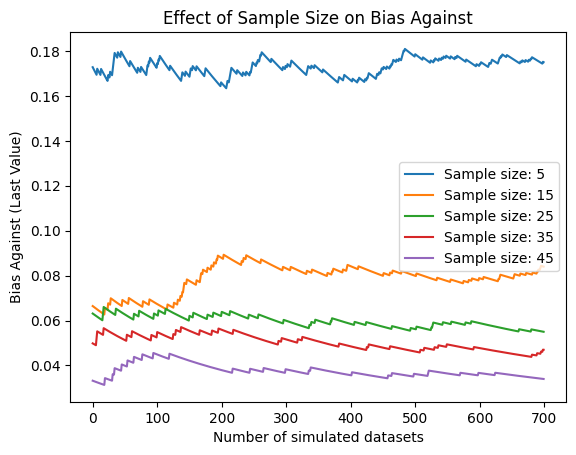

In [ ]:

# Parameters
mu_prior_mean = [1, 2]
mu_prior_sigma = 1
sigma_prior_alpha = 3
sigma_prior_beta = 2
p = 2
delta = 0.05
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Define n values
n_values = list(range(5, 50 + 1, 10))
bias_against_last_values = []
print(n_values)
for n in n_values:
    # Create X matrix with size (n, p)
    X = np.ones((n, p))
    X[:int(n/2), 0] = 0
    X[0:-1:2, 1] = 0
    bias_against_last = hypothesis_bias_against_lin_reg(
        n_sample=n,
        beta0=beta0,
        X=X,
        sigma0=sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        cumulative=True,
        n_datasets=1000
    )
    plt.plot(bias_against_last, label = f"Sample size: {n}")

# Plotting
plt.xlabel("Number of simulated datasets")
plt.ylabel("Bias Against (Last Value)")
plt.title("Effect of Sample Size on Bias Against")
plt.legend()
plt.show()


### Hyperparameters

0
1
2
3
4
5


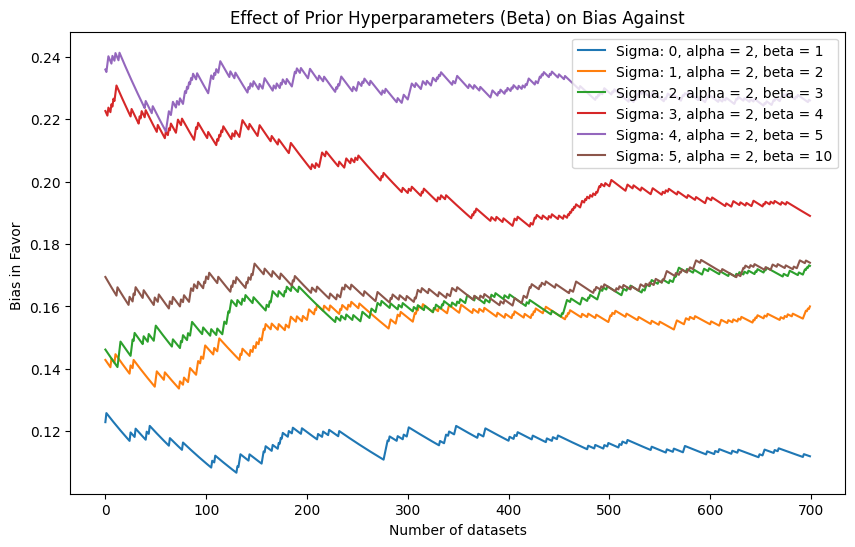

In [ ]:
# Parameters
biases = []

n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Experiment: Vary sigma_prior_alpha and sigma_prior_beta
alpha_values = [2, 2, 2, 2, 2, 2]
beta_values = [1, 2, 3, 4, 5, 10]

plt.figure(figsize=(10, 6))
for i in range(len(alpha_values)):
        print(i)
        sigma0 = beta_values[i]/(alpha_values[i] -1)
        bias_against = hypothesis_bias_against_lin_reg(
            n,
            beta0,
            X,
            sigma0,
            mu_prior_mean=mu_prior_mean,
            mu_prior_sigma=mu_prior_sigma,
            sigma_prior_alpha=alpha_values[i],
            sigma_prior_beta=beta_values[i],
            cumulative=True,
            n_datasets=1000
        )
        plt.plot(bias_against, label = f"Sigma: {i}, alpha = {alpha_values[i]}, beta = {beta_values[i]}")
plt.xlabel('Number of datasets')
plt.ylabel('Bias in Favor ')
plt.legend()
plt.title('Effect of Prior Hyperparameters (Beta) on Bias Against')
plt.show()


0
1
2
3
4
5


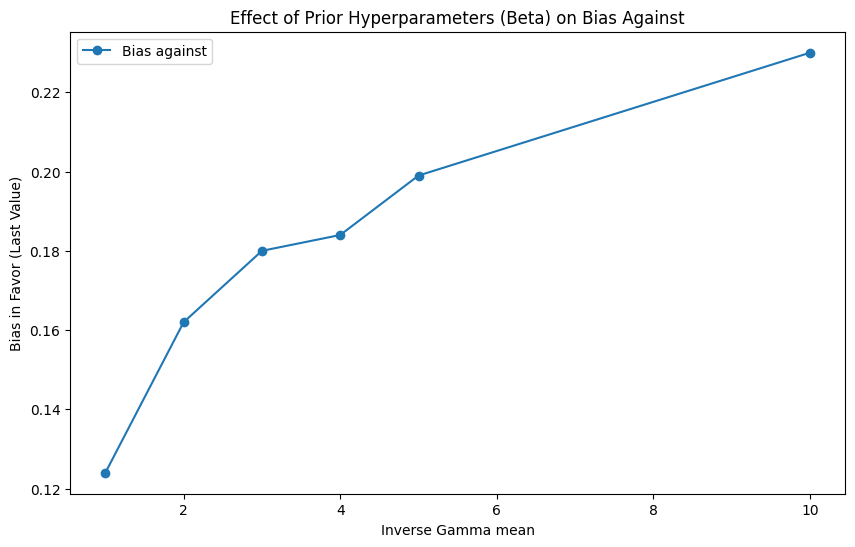

In [ ]:
# Parameters
biases = []

n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Experiment: Vary sigma_prior_alpha and sigma_prior_beta
alpha_values = [2, 2, 2, 2, 2, 2]
beta_values = [1, 2, 3, 4, 5, 10]

plt.figure(figsize=(10, 6))
for i in range(len(alpha_values)):
        print(i)
        sigma0 = beta_values[i]/(alpha_values[i] -1)
        bias_against = hypothesis_bias_against_lin_reg(
            n,
            beta0,
            X,
            sigma0,
            mu_prior_mean=mu_prior_mean,
            mu_prior_sigma=mu_prior_sigma,
            sigma_prior_alpha=alpha_values[i],
            sigma_prior_beta=beta_values[i],
            cumulative=False,
            n_datasets=1000
        )
        biases.append(bias_against)
plt.plot(beta_values, biases, label = "Bias against", marker = "o")
plt.xlabel('Inverse Gamma mean')
plt.ylabel('Bias in Favor (Last Value)')
plt.legend()
plt.title('Effect of Prior Hyperparameters (Beta) on Bias Against')
plt.show()


# Bias in favor

Prior:
\begin{align*}
p(\boldsymbol \beta) = {}& \mathbf{MVN}\left(E[\boldsymbol \beta ] = \boldsymbol \beta_0, \text{Cov}[\boldsymbol \beta ] = \boldsymbol \Sigma_\beta \right) \quad \\
p(\boldsymbol \sigma ^2) = {}& \mathbf{InverseGamma}\left(\boldsymbol \alpha = 3, \beta = 2 \right) \quad
\end{align*}

Posterior:
\begin{align*}
p(\boldsymbol \beta |\boldsymbol\Sigma, \mathbf{X},\mathbf{y^*}) = {}& \mathbf{MVN}\left(\overset{E[\boldsymbol \beta^* | \boldsymbol\Sigma, \mathbf{X},\mathbf{y^*}] \; = \quad\quad}{\text{Cov}[\boldsymbol \beta ^* | \boldsymbol\Sigma, \mathbf{X},\mathbf{y^*}]}\bigg( \mathbf{X}^\top \boldsymbol\Sigma^{-1}\mathbf{y^*} + \boldsymbol \Sigma_\beta^{-1}\boldsymbol\beta^* \right), \text{Cov}[\boldsymbol \beta ^* | \boldsymbol\Sigma, \mathbf{X},\mathbf{y^*}] = \left[\mathbf{X}^{\top}\boldsymbol \Sigma^{-1} \mathbf{X}  + \boldsymbol \Sigma_\beta^{-1} \right]^{-1} \bigg)\\
\end{align*}

Y:
\begin{align*}\require{cancel}
\mathbf{y}_{n\times 1} \sim {} & \mathbf{MVN}(\mathbf{X}_{n\times p}\boldsymbol{\beta}_{p\times 1},\boldsymbol \Sigma_{n\times n} = \sigma^2I_{n\times n})\\
\end{align*}

[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]
[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]


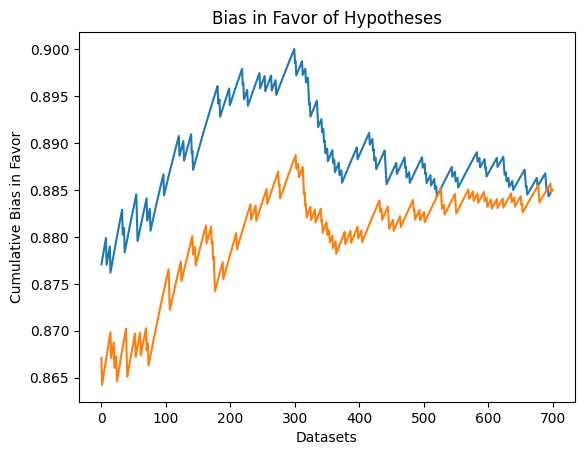

In [1]:
import numpy as np
from scipy.stats import multivariate_normal, invgamma, norm
from scipy.special import logsumexp
import matplotlib.pyplot as plt

def hypothesis_bias_in_favor_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    mu_prior_mean,
    mu_prior_sigma,
    sigma_prior_alpha,
    sigma_prior_beta,
    delta=0.05,
    cumulative=True,
    n_datasets=1000,
    n_marginal=1000
):
    """
    Calculate the bias in favor of a hypothesis for the linear regression model.

    Parameters:
    - n_sample (int): Sample size.
    - beta0 (np.ndarray): True beta coefficients (p, ).
    - X (np.ndarray): Design matrix (n_sample, p).
    - sigma0 (float): True noise variance.
    - mu_prior_mean (np.ndarray): Mean of the prior distribution for beta (p, ).
    - mu_prior_sigma (np.ndarray): Covariance matrix of the prior distribution for beta (p, p).
    - sigma_prior_alpha (float): Alpha parameter of the Inverse-Gamma prior for sigma^2.
    - sigma_prior_beta (float): Beta (scale) parameter of the Inverse-Gamma prior for sigma^2.
    - delta (float): Adjustment to create alternative hypotheses.
    - cumulative (bool): Whether to return cumulative bias values.
    - n_datasets (int): Number of datasets to simulate.
    - n_marginal (int): Number of samples to estimate the marginal likelihood.

    Returns:
    - float or np.ndarray: Final bias in favor estimate or cumulative bias values.
    """

    p = X.shape[1]  # Number of predictors
    n = X.shape[0]  # Number of samples

    # Step 1: Create perturbed beta values (for hypotheses in favor)
    beta_perturbed = []
    for i in range(p):
        for sign in [-1, 1]:  # Perturb each coefficient positively and negatively
            beta_new = beta0.copy()
            beta_new[i] += sign * delta
            beta_perturbed.append(beta_new)

    beta_perturbed = np.array(beta_perturbed)
    print(beta_perturbed)
    # Step 2: Generate synthetic datasets
    y = np.dot(X, beta0) + np.random.normal(0, np.sqrt(sigma0), size=(n_datasets, n_sample))

    # Step 3: Compute log-likelihood under the perturbed hypotheses
    log_likelihoods = np.zeros((len(beta_perturbed), n_datasets))
    for idx, beta_hyp in enumerate(beta_perturbed):
        log_likelihoods[idx, :] = multivariate_normal.logpdf(
            y, mean=np.dot(X, beta_hyp), cov=sigma0 * np.eye(n_sample)
        )

    # Step 4: Sample beta and sigma^2 from their respective priors
    beta_samples = multivariate_normal.rvs(mean=mu_prior_mean, cov=mu_prior_sigma, size=n_marginal)
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=n_marginal)

    # Step 5: Compute the marginal likelihood p(y | X) via Monte Carlo integration
    log_marginal_likelihoods = np.zeros((n_datasets,))
    for d in range(n_datasets):
        marginal_likelihood_samples = np.zeros((n_marginal,))
        for i in range(n_marginal):
            mean_sample = np.dot(X, beta_samples[i])
            marginal_likelihood_samples[i] = multivariate_normal.logpdf(
                y[d], mean=mean_sample, cov=sigma_samples[i] * np.eye(n_sample)
            )
        log_marginal_likelihoods[d] = logsumexp(marginal_likelihood_samples) - np.log(n_marginal)

    # Step 6: Calculate bias in favor
    bias_in_favor = np.any(log_likelihoods >= log_marginal_likelihoods, axis=0)

    # Step 7: Compute cumulative bias in favor if requested
    bias_in_favor_cumsum = np.cumsum(bias_in_favor) / np.arange(1, n_datasets + 1)

    if cumulative:
        return bias_in_favor_cumsum[300:]
    else:
        return bias_in_favor_cumsum[-1]


# Parameters
mu_prior_mean = [1, 2]
mu_prior_sigma = np.eye(2)
sigma_prior_alpha = 3
sigma_prior_beta = 2

n = 10
p = 2
X = np.ones((n, p))
X[:int(n / 2), 0] = 0
X[0:-1:2, 1] = 0

# Ground truth parameters
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Run and plot
loops = 2
for i in range(loops):
    bias_in_favor = hypothesis_bias_in_favor_lin_reg(
        n_sample=n,
        beta0=beta0,
        X=X,
        sigma0=sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        delta=0.05,
        cumulative=True,
        n_datasets=1000,
        n_marginal=1000,
    )
    plt.plot(bias_in_favor)

plt.xlabel("Datasets")
plt.ylabel("Cumulative Bias in Favor")
plt.title("Bias in Favor of Hypotheses")
plt.show()


### Delta

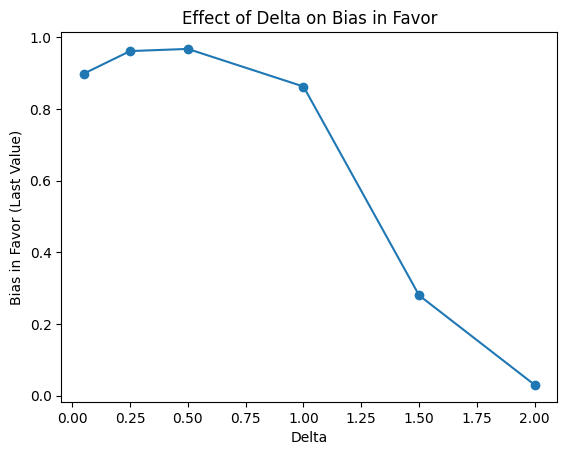

In [ ]:
# Parameters
mu_prior_mean = [1, 2]
mu_prior_sigma = 1
sigma_prior_alpha = 3
sigma_prior_beta = 2
n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Define delta values
delta_values = [0.05, 0.25, 0.50, 1, 1.5, 2]
bias_in_favor_last_values = []

for delta in delta_values:
    bias_in_favor_last = hypothesis_bias_in_favor_lin_reg(
        n_sample=n,
        beta0=beta0,
        X=X,
        sigma0=sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        delta=delta,
        cumulative=False,
        n_datasets=1000
    )
    bias_in_favor_last_values.append(bias_in_favor_last)

# Plotting
plt.plot(delta_values, bias_in_favor_last_values, marker='o')
plt.xlabel("Delta")
plt.ylabel("Bias in Favor (Last Value)")
plt.title("Effect of Delta on Bias in Favor")
plt.show()


[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]
[[0.75 2.  ]
 [1.25 2.  ]
 [1.   1.75]
 [1.   2.25]]
[[0.5 2. ]
 [1.5 2. ]
 [1.  1.5]
 [1.  2.5]]
[[0. 2.]
 [2. 2.]
 [1. 1.]
 [1. 3.]]
[[-0.5  2. ]
 [ 2.5  2. ]
 [ 1.   0.5]
 [ 1.   3.5]]
[[-1.  2.]
 [ 3.  2.]
 [ 1.  0.]
 [ 1.  4.]]


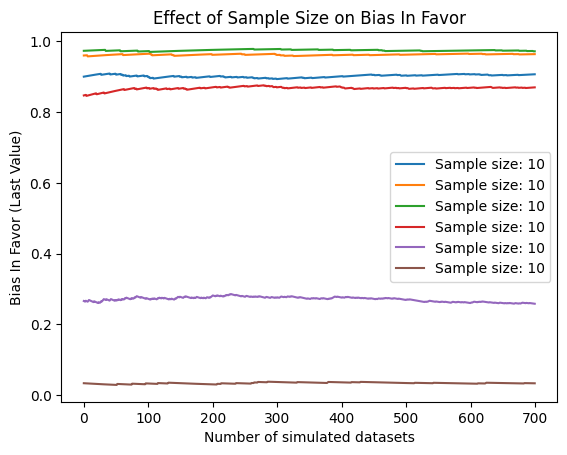

In [2]:
# Parameters
mu_prior_mean = [1, 2]
mu_prior_sigma = 1
sigma_prior_alpha = 3
sigma_prior_beta = 2
n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Define delta values
delta_values = [0.05, 0.25, 0.50, 1, 1.5, 2]
bias_in_favor_last_values = []

for delta in delta_values:
    bias_in_favor_last = hypothesis_bias_in_favor_lin_reg(
        n_sample=n,
        beta0=beta0,
        X=X,
        sigma0=sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        delta=delta,
        cumulative=True,
        n_datasets=1000
    )
    plt.plot(bias_in_favor_last, label = f"Delta values: {delta}")

# Plotting
plt.xlabel("Number of simulated datasets")
plt.ylabel("Bias In Favor (Last Value)")
plt.title("Effect of Sample Size on Bias In Favor")
plt.legend()
plt.show()


### Hyperparameters

0
[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]
1
[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]
2
[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]
3
[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]
4
[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]
5
[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]


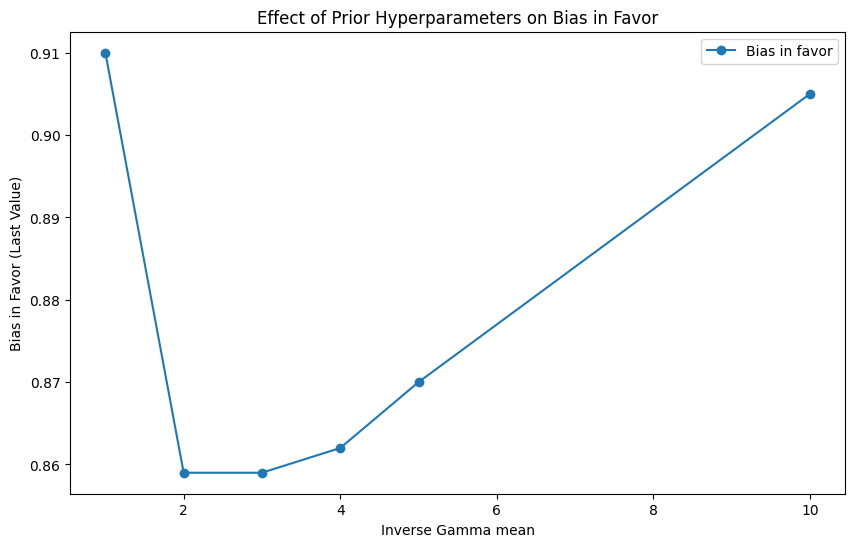

In [5]:
# Parameters
maxs = []
mu_prior_mean = [1, 2]
mu_prior_sigma = 1
n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Experiment: Vary sigma_prior_alpha and sigma_prior_beta
beta_values = [2, 2, 2, 2, 2,2 ]
alpha_values = [3, 2, 1.67, 1.5, 1.4, 1.2]
plt.figure(figsize=(10, 6))
for i in range(len(alpha_values)):
        print(i)
        sigma0 = beta_values[i]/(alpha_values[i] - 1)
        bias_in_favor = hypothesis_bias_in_favor_lin_reg(
            n,
            beta0,
            X,
            sigma0,
            mu_prior_mean=mu_prior_mean,
            mu_prior_sigma=mu_prior_sigma,
            sigma_prior_alpha=alpha_values[i],
            sigma_prior_beta=beta_values[i],
            delta=0.05,
            cumulative=False,
            n_datasets=1000
        )
        maxs.append(bias_in_favor)
plt.plot([1, 2, 3, 4, 5, 10] , maxs, label = "Bias in favor", marker='o')
plt.xlabel('Inverse Gamma mean')
plt.ylabel('Bias in Favor (Last Value)')
plt.legend()
plt.title('Effect of Prior Hyperparameters on Bias in Favor')
plt.show()


0
[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]
1
[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]
2
[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]
3
[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]
4
[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]
5
[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]


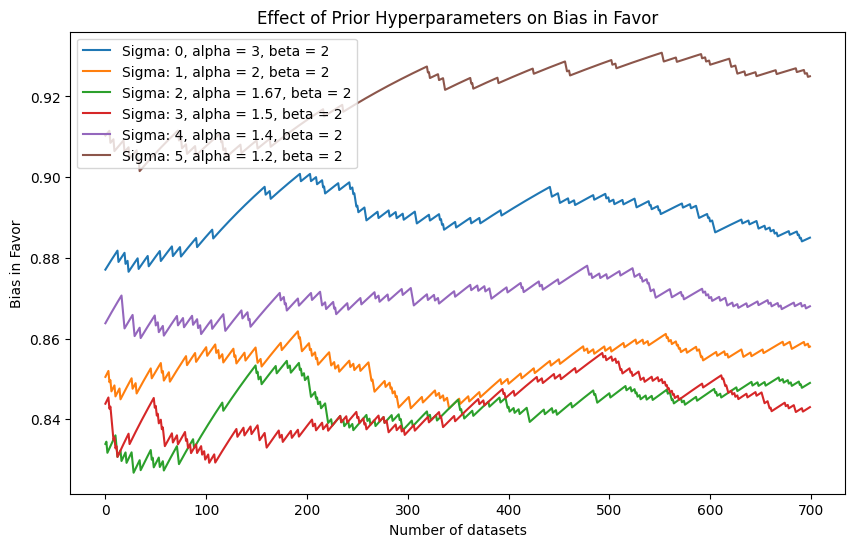

In [6]:
# Parameters
mins = []
maxs = []
mu_prior_mean = [1, 2]
mu_prior_sigma = 1
n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Experiment: Vary sigma_prior_alpha and sigma_prior_beta
beta_values = [2, 2, 2, 2, 2,2 ]
alpha_values = [3, 2, 1.67, 1.5, 1.4, 1.2]
plt.figure(figsize=(10, 6))
for i in range(len(alpha_values)):
        print(i)
        sigma0 = beta_values[i]/(alpha_values[i] - 1)
        bias_in_favor = hypothesis_bias_in_favor_lin_reg(
            n,
            beta0,
            X,
            sigma0,
            mu_prior_mean=mu_prior_mean,
            mu_prior_sigma=mu_prior_sigma,
            sigma_prior_alpha=alpha_values[i],
            sigma_prior_beta=beta_values[i],
            delta=0.05,
            cumulative=True,
            n_datasets=1000
        )
        plt.plot(bias_in_favor, label = f"Sigma: {i}, alpha = {alpha_values[i]}, beta = {beta_values[i]}")
plt.xlabel('Number of datasets')
plt.ylabel('Bias in Favor')
plt.legend()
plt.title('Effect of Prior Hyperparameters on Bias in Favor')
plt.show()


### Sample size

In [7]:

# Parameters
mu_prior_mean = [1, 2]
mu_prior_sigma = 1
sigma_prior_alpha = 3
sigma_prior_beta = 2
p = 2
delta = 0.05
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Define n values
n_values = list(range(10, 100 + 1, 10))
print(n_values)
bias_in_favor_last_values = []
for n in n_values:
    print(n)
    # Create X matrix with size (n, p)
    X = np.ones((n, p))
    X[:int(n/2), 0] = 0
    X[0:-1:2, 1] = 0
    bias_in_favor_last = hypothesis_bias_in_favor_lin_reg(
        n_sample=n,
        beta0=beta0,
        X=X,
        sigma0=sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        delta=delta,
        cumulative=False,
        n_datasets=1000
    )
    bias_in_favor_last_values.append(bias_in_favor_last)

# Plotting
plt.plot(n_values, bias_in_favor_last_values, marker='o')
plt.xlabel("Sample Size (n)")
plt.ylabel("Bias in Favor (Last Value)")
plt.title("Effect of Sample Size on Bias in Favor with Delta = 0.05")
plt.show()


[10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
10
[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]
20
[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]
30
[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]
40
[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]
50
[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]
60
[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]
70
[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]
80
[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]
90
[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]


KeyboardInterrupt: 

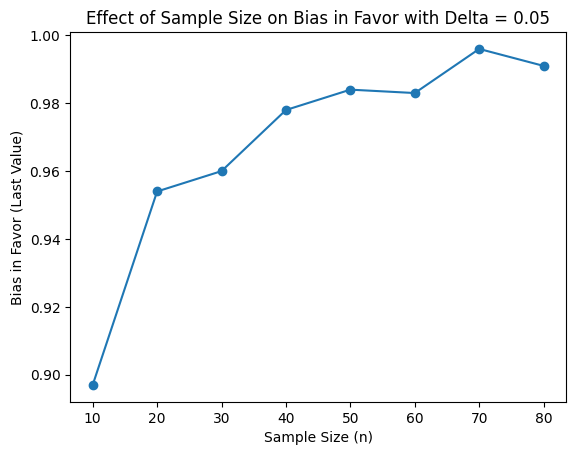

In [9]:

# Plotting
plt.plot(n_values[:8], bias_in_favor_last_values, marker='o')
plt.xlabel("Sample Size (n)")
plt.ylabel("Bias in Favor (Last Value)")
plt.title("Effect of Sample Size on Bias in Favor with Delta = 0.05")
plt.show()

In [ ]:

# Parameters
mu_prior_mean = [1, 2]
mu_prior_sigma = 1
sigma_prior_alpha = 3
sigma_prior_beta = 2
p = 2
delta = 0.05
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Define n values
n_values = list(range(10, 100 + 1, 10))
print(n_values)
bias_in_favor_last_values = []
for n in n_values:
    print(n)
    # Create X matrix with size (n, p)
    X = np.ones((n, p))
    X[:int(n/2), 0] = 0
    X[0:-1:2, 1] = 0
    bias_in_favor_last = hypothesis_bias_in_favor_lin_reg(
        n_sample=n,
        beta0=beta0,
        X=X,
        sigma0=sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        delta=delta,
        cumulative=True,
        n_datasets=1000
    )
    plt.plot(bias_in_favor_last, label = f"Sample size: {n}")
plt.xlabel('Number of datasets')
plt.ylabel('Bias in Favor')
plt.legend()
plt.title('Effect of Sample Size on Bias in Favor')
plt.show()



## Estimation

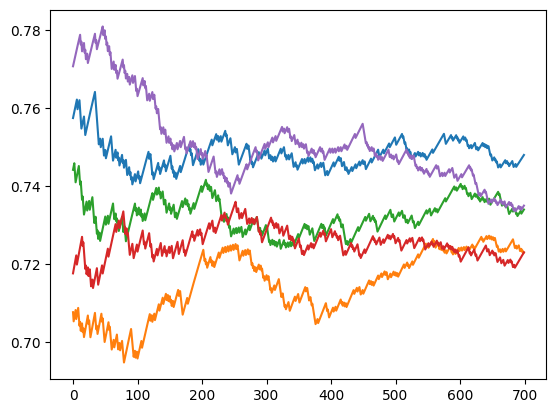

In [6]:
import numpy as np
from scipy.stats import multivariate_normal, invgamma
from scipy.special import logsumexp
import matplotlib.pyplot as plt

def estimation_bias_against_lin_reg(
    n_sample,
    X,
    mu_prior_mean,
    mu_prior_sigma,
    sigma_prior_alpha,
    sigma_prior_beta,
    cumulative=True,
    n_datasets=1000,
    n_marginal=1000
):
    """
    Calculate the bias against estimation using the sufficient statistic approach for the linear regression model.

    Parameters:
    - n_sample (int): Sample size.
    - beta0 (np.ndarray): Hypothesized beta coefficients (p, ).
    - X (np.ndarray): Design matrix (n_sample, p).
    - sigma0 (float): Hypothesized noise variance.
    - mu_prior_mean (np.ndarray): Mean of the prior distribution for beta (p, ).
    - mu_prior_sigma (np.ndarray): Covariance matrix of the prior distribution for beta (p, p).
    - sigma_prior_alpha (float): Alpha parameter of the Inverse-Gamma prior for sigma^2.
    - sigma_prior_beta (float): Beta (scale) parameter of the Inverse-Gamma prior for sigma^2.
    - cumulative (bool): Whether to return cumulative bias values.
    - n_datasets (int): Number of datasets to simulate.
    - n_marginal (int): Number of samples to estimate the marginal likelihood.

    Returns:
    - float or np.ndarray: Final bias against estimate or cumulative bias against values.
    """


    # Step 1: Sample p₀ from the prior distribution
    beta_samples = multivariate_normal.rvs(mean=mu_prior_mean, cov=mu_prior_sigma, size=n_marginal)
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=n_marginal)

    # Step 2: Generate x from p(x | p₀)
    #y = np.dot(X, beta_samples) + np.random.normal(0, np.sqrt(sigma_samples), size=(n_datasets, n_sample))
    y = np.dot(X, beta_samples.T).T + np.random.normal(0, np.sqrt(sigma_samples)[:, np.newaxis], size=(n_datasets, n_sample))

    # Step 3: Compute log-likelihoods of x under p₀
    log_likelihood = multivariate_normal.logpdf(
        y[:, np.newaxis], mean=np.dot(X, beta0), cov=sigma0 * np.eye(n_sample)
    )  # Shape: (n_datasets,)

    # Step 4: Sample p_j from the prior distribution
    #p_j_samples = np.random.beta(prior_alpha, prior_beta, size=n_marginal)
    beta_j_samples = multivariate_normal.rvs(mean=mu_prior_mean, cov=mu_prior_sigma, size=n_marginal)
    sigma_j_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=n_marginal)

    # Step 5: Compute the marginal likelihood p(x) via Monte Carlo integration
    # Compute log p(x | p_j) for each p_j and x
    # Shape: (n_datasets, n_marginal)
    log_likelihoods = np.zeros((n_datasets, n_marginal))

    for i in range(n_marginal):
        mu_samples = np.dot(X, beta_j_samples[i])
        log_likelihoods[:, i] = multivariate_normal.logpdf(
            y, mean=mu_samples, cov=sigma_j_samples[i] * np.eye(n_sample)
        )


    # Compute log marginal likelihood for each x using log-sum-exp trick
    # log p(x) = log(1/n_marginal * sum_{j} exp(log p(x | p_j)))
    log_marginal_likelihood = logsumexp(log_likelihoods, axis=1) - np.log(n_marginal)

    # Step 6: Compute the bias against
    bias_against = (log_likelihood - log_marginal_likelihood) <= 0

    # Compute cumulative bias against if requested
    bias_against_cumsum = np.cumsum(bias_against) / np.arange(1, n_datasets + 1)

    if cumulative:
        return bias_against_cumsum[300:]
    else:
        return bias_against_cumsum[-1]




# Parameters
# Define prior parameters
mu_prior_mean = [1, 2]
mu_prior_sigma = 1
sigma_prior_alpha = 3
sigma_prior_beta = 2

n=10; p = 2
X = np.ones((n, p))
X[:int(n/2),0] = 0
X[0:-1:2,1] = 0


loops = 5
for i in range(loops):
    # Calculate bias against
    bias_against = estimation_bias_against_lin_reg(
        n,
        X,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha = sigma_prior_alpha,
        sigma_prior_beta = sigma_prior_beta,
        cumulative = True,
        n_datasets=1000,
        n_marginal=1000
        )
    plt.plot(bias_against)

## Bias In Favor

(50, 2)
(50,)
(500, 2)
(1, 500, 2)
(500, 2)
(50, 1, 10)
(500, 2)
(1, 500, 2)
(500, 2)
(50, 1, 10)
2
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
(500, 2)
(1, 500, 2)
(500, 2)
(50, 1, 10)
(500, 2)
(1, 500, 2)
(500, 2)
(50, 1, 10)
2
[0.94 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.  ]
(500, 2)
(1, 500, 2)
(500, 2)
(50, 1, 10)
(500, 2)
(1, 500, 2)
(500, 2)
(50, 1, 10)
2
[0.94 1.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
 0.   0.   0.   0.   0.   0.   0.   0.  ]
(500, 2)
(1, 500, 2)
(500, 2)
(50, 1, 10)
(500, 2)
(1, 500, 2)
(500, 2)
(50,

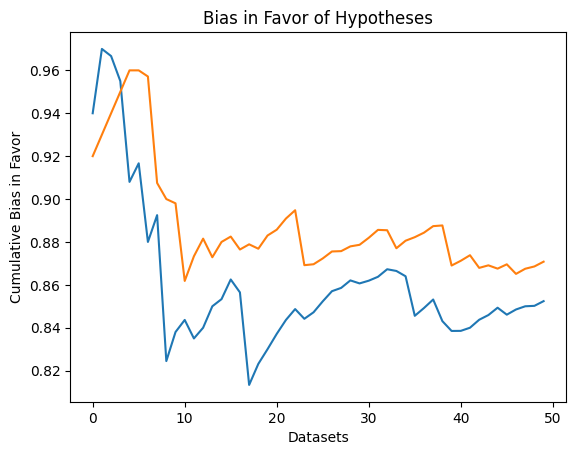

In [35]:
import numpy as np
from scipy.stats import binom, beta
from scipy.special import logsumexp

def estimation_bias_in_favor_lin_reg(
        n_sample,
        delta,
        n_iter,
        X,
        mu_prior_mean,
        mu_prior_sigma,
        sigma_prior_alpha,
        sigma_prior_beta,
        n_marginal=500,
        n_datasets=50,
        cumulative=False # Return cumulative bias if True, otherwise return the final bias value
):
    """
    Estimates bias in favor of a binomial parameter estimate using sufficient statistics.
    """

    # Step 1: Pre-sample all p₀ values from the prior distribution
    #p0_samples = np.random.beta(prior_alpha, prior_beta, size=n_iter)
    beta0_samples = multivariate_normal.rvs(mean=mu_prior_mean, cov=mu_prior_sigma, size=n_iter)
    sigma0_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=n_iter)


    # Step 2: Pre-sample p_j_samples for marginal likelihood estimation
    #p_j_samples = np.random.beta(prior_alpha, prior_beta, size=n_marginal)
    beta_j_samples = multivariate_normal.rvs(mean=mu_prior_mean, cov=mu_prior_sigma, size=n_marginal)
    sigma_j_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=n_marginal)


    # Initialize an array to store the maximum biases from each iteration
    max_biases = np.zeros(n_iter)
    print(beta0_samples.shape)
    print(sigma0_samples.shape)
    for i, beta0 in enumerate(beta0_samples):

        # Array to store biases for beta = beta₀ + delta and beta₀ - delta
        biases = []

        for delta_sign in [+delta, -delta]:
            # Step 3: Set p = p₀ + delta or p₀ - delta
            beta = beta0 + delta_sign
            # Step 4: Generate x from p(x | p)
            # x shape: (n_datasets,)
            #x = np.random.binomial(n_sample, p, size=n_datasets)
            y = np.dot(X, beta) + np.random.normal(0, np.sqrt(sigma_j_samples[i]), size=(n_datasets, n_sample))

            # Step 5: Compute log p(x | p₀) for each dataset
            # log_p_x_given_p0 shape: (n_datasets,)
            #log_p_x_given_p0 = binom.logpmf(x, n_sample, p0)
            log_likelihoods_beta0 = multivariate_normal.logpdf(
                    y, mean=np.dot(X, beta0), cov=sigma0 * np.eye(n_sample))
            #log_likelihoods_beta0 = np.zeros((len(beta), n_datasets))
            #for idx, beta_hyp in enumerate(beta0):
            #    log_likelihoods_beta0[idx, :] = multivariate_normal.logpdf(
            #        y, mean=np.dot(X, beta_hyp), cov=sigma0 * np.eye(n_sample)
            #    )
            # Step 6: Estimate log p(x) via Monte Carlo integration
            # Compute log p(x | p_j) for all p_j and datasets
            # log_p_x_given_p_j shape: (n_datasets, n_marginal)
            #x_expanded = x[:, np.newaxis]  # Shape: (n_datasets, 1)
            #p_j_expanded = p_j_samples[np.newaxis, :]  # Shape: (1, n_marginal)


            log_marginal_likelihoods = np.zeros((n_datasets,))
            for d in range(n_datasets):
                marginal_likelihood_samples = np.zeros((n_marginal,))
                for j in range(n_marginal):
                    mean_sample = np.dot(X, beta_j_samples[j])
                    marginal_likelihood_samples[j] = multivariate_normal.logpdf(
                        y[d], mean=mean_sample, cov=sigma_j_samples[j] * np.eye(n_sample)
                    )
                log_marginal_likelihoods[d] = logsumexp(marginal_likelihood_samples) - np.log(n_marginal)



            #log_p_x_given_p_j = binom.logpmf(x_expanded, n_sample, p_j_expanded)
            y_expanded = y[:, np.newaxis]
            betaj_expanded = beta_j_samples[np.newaxis, :]
            print(beta_j_samples.shape)
            print(betaj_expanded.shape)
            print(betaj_expanded[0].shape)

            print(y_expanded.shape)

            log_likelihoods = np.zeros((n_datasets, n_marginal))

            for k in range(n_marginal):
                mu_samples = np.dot(X, beta_j_samples[k])
                log_likelihoods[:, k] = multivariate_normal.logpdf(
                    y, mean=mu_samples, cov=sigma_j_samples[k] * np.eye(n_sample)
                )

            # Compute log p(x) for each dataset
            # log_p_x shape: (n_datasets,)
            #log_p_x = logsumexp(log_p_x_given_p_j, axis=1) - np.log(n_marginal)

            # Step 7: Compute the log relative belief ratio for each dataset
            #log_rb = log_p_x_given_p0 - log_p_x
            log_rb = log_likelihoods_beta0 - log_marginal_likelihoods
            # Step 8: Determine bias for each dataset
            biases_datasets = (log_rb > 0).astype(int)

            # Step 9: Compute the bias for this p as the mean over datasets
            bias = biases_datasets.mean()

            # Store the bias for this delta sign
            biases.append(bias)
        print(len(biases))
        print(max_biases)
        if biases:
            # Step 10: Store the maximum of the biases (if any valid delta_sign)
            max_biases[i] = max(biases)
        else:
            # If both delta_signs were invalid (p out of bounds), store NaN
            max_biases[i] = np.nan

    # Remove NaN values from max_biases
    valid_max_biases = max_biases[~np.isnan(max_biases)]

    # Step 11: Compute the final bias in favor estimate
    bias_in_favor_estimate = valid_max_biases.mean()

    # Return cumulative bias if `cumulative=True`, otherwise return the final bias value
    if cumulative:
        # Compute cumulative mean over valid_max_biases
        cumulative_bias = np.cumsum(valid_max_biases) / np.arange(1, len(valid_max_biases) + 1)
        return cumulative_bias
    else:
        return bias_in_favor_estimate


# Parameters
mu_prior_mean = [1, 2]
mu_prior_sigma = np.eye(2)
sigma_prior_alpha = 3
sigma_prior_beta = 2

n = 10
p = 2
X = np.ones((n, p))
X[:int(n / 2), 0] = 0
X[0:-1:2, 1] = 0

# Run and plot
loops = 2
for i in range(loops):
    bias_in_favor = estimation_bias_in_favor_lin_reg(
        n_sample = n,
        delta = 0.05,
        n_iter=50,
        X = X,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        n_marginal=500,
        n_datasets=50,
        cumulative=True
    )
    plt.plot(bias_in_favor)

plt.xlabel("Datasets")
plt.ylabel("Cumulative Bias in Favor")
plt.title("Bias in Favor of Hypotheses")
plt.show()


## Misc

[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]
[[0.95 2.  ]
 [1.05 2.  ]
 [1.   1.95]
 [1.   2.05]]


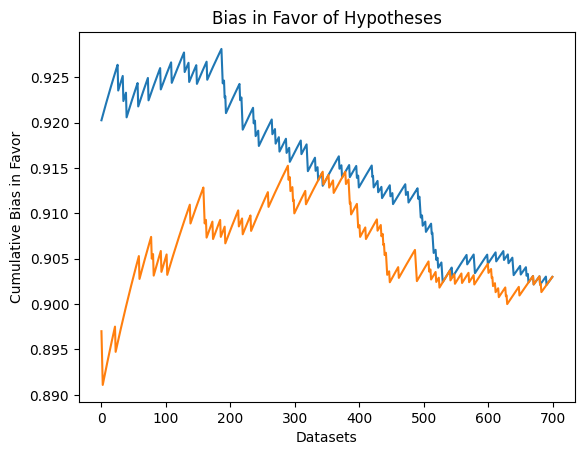

In [8]:
import numpy as np
from scipy.stats import multivariate_normal, invgamma, norm
from scipy.special import logsumexp
import matplotlib.pyplot as plt

def hypothesis_bias_in_favor_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    mu_prior_mean,
    mu_prior_sigma,
    sigma_prior_alpha,
    sigma_prior_beta,
    delta=0.05,
    cumulative=True,
    n_datasets=1000,
    n_marginal=1000
):
    """
    Calculate the bias in favor of a hypothesis for the linear regression model.

    Parameters:
    - n_sample (int): Sample size.
    - beta0 (np.ndarray): True beta coefficients (p, ).
    - X (np.ndarray): Design matrix (n_sample, p).
    - sigma0 (float): True noise variance.
    - mu_prior_mean (np.ndarray): Mean of the prior distribution for beta (p, ).
    - mu_prior_sigma (np.ndarray): Covariance matrix of the prior distribution for beta (p, p).
    - sigma_prior_alpha (float): Alpha parameter of the Inverse-Gamma prior for sigma^2.
    - sigma_prior_beta (float): Beta (scale) parameter of the Inverse-Gamma prior for sigma^2.
    - delta (float): Adjustment to create alternative hypotheses.
    - cumulative (bool): Whether to return cumulative bias values.
    - n_datasets (int): Number of datasets to simulate.
    - n_marginal (int): Number of samples to estimate the marginal likelihood.

    Returns:
    - float or np.ndarray: Final bias in favor estimate or cumulative bias values.
    """

    p = X.shape[1]  # Number of predictors
    n = X.shape[0]  # Number of samples

    # Step 1: Create perturbed beta values (for hypotheses in favor)
    beta_perturbed = []
    for i in range(p):
        for sign in [-1, 1]:  # Perturb each coefficient positively and negatively
            beta_new = beta0.copy()
            beta_new[i] += sign * delta
            beta_perturbed.append(beta_new)

    beta_perturbed = np.array(beta_perturbed)
    print(beta_perturbed)
    # Step 2: Generate synthetic datasets
    y = np.dot(X, beta0) + np.random.normal(0, np.sqrt(sigma0), size=(n_datasets, n_sample))

    # Step 3: Compute log-likelihood under the perturbed hypotheses
    log_likelihoods = np.zeros((len(beta_perturbed), n_datasets))
    for idx, beta_hyp in enumerate(beta_perturbed):
        log_likelihoods[idx, :] = multivariate_normal.logpdf(
            y, mean=np.dot(X, beta_hyp), cov=sigma0 * np.eye(n_sample)
        )

    # Step 4: Sample beta and sigma^2 from their respective priors
    beta_samples = multivariate_normal.rvs(mean=mu_prior_mean, cov=mu_prior_sigma, size=n_marginal)
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=n_marginal)

    # Step 5: Compute the marginal likelihood p(y | X) via Monte Carlo integration
    log_marginal_likelihoods = np.zeros((n_datasets,))
    for d in range(n_datasets):
        marginal_likelihood_samples = np.zeros((n_marginal,))
        for i in range(n_marginal):
            mean_sample = np.dot(X, beta_samples[i])
            marginal_likelihood_samples[i] = multivariate_normal.logpdf(
                y[d], mean=mean_sample, cov=sigma_samples[i] * np.eye(n_sample)
            )
        log_marginal_likelihoods[d] = logsumexp(marginal_likelihood_samples) - np.log(n_marginal)

    # Step 6: Calculate bias in favor
    bias_in_favor = np.any(log_likelihoods >= log_marginal_likelihoods, axis=0)

    # Step 7: Compute cumulative bias in favor if requested
    bias_in_favor_cumsum = np.cumsum(bias_in_favor) / np.arange(1, n_datasets + 1)

    if cumulative:
        return bias_in_favor_cumsum[300:]
    else:
        return bias_in_favor_cumsum[-1]


# Parameters
mu_prior_mean = [1, 2]
mu_prior_sigma = np.eye(2)
sigma_prior_alpha = 3
sigma_prior_beta = 2

n = 10
p = 2
X = np.ones((n, p))
X[:int(n / 2), 0] = 0
X[0:-1:2, 1] = 0

# Ground truth parameters
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Run and plot
loops = 2
for i in range(loops):
    bias_in_favor = hypothesis_bias_in_favor_lin_reg(
        n_sample=n,
        beta0=beta0,
        X=X,
        sigma0=sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        delta=0.05,
        cumulative=True,
        n_datasets=1000,
        n_marginal=1000,
    )
    plt.plot(bias_in_favor)

plt.xlabel("Datasets")
plt.ylabel("Cumulative Bias in Favor")
plt.title("Bias in Favor of Hypotheses")
plt.show()


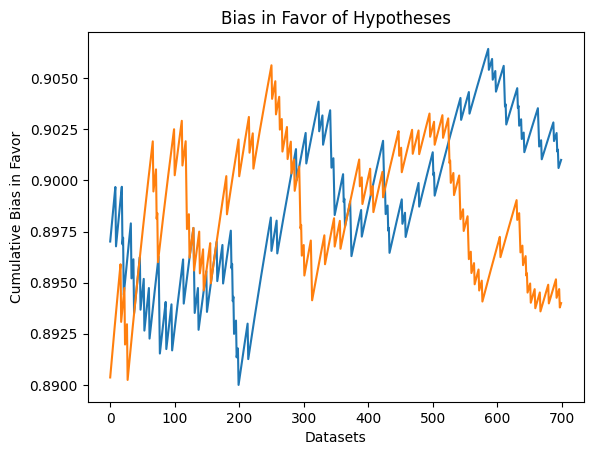

In [7]:
import numpy as np
from scipy.stats import multivariate_normal, invgamma
from scipy.special import logsumexp
import matplotlib.pyplot as plt

def hypothesis_bias_in_favor_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    mu_prior_mean,
    mu_prior_sigma,
    sigma_prior_alpha,
    sigma_prior_beta,
    delta=0.05,
    cumulative=True,
    n_datasets=1000,
    n_marginal=1000
):
    """
    Calculate the bias in favor of a hypothesis for the linear regression model.

    Parameters:
    - n_sample (int): Sample size.
    - beta0 (np.ndarray): True beta coefficients (p, ).
    - X (np.ndarray): Design matrix (n_sample, p).
    - sigma0 (float): True noise variance.
    - mu_prior_mean (np.ndarray): Mean of the prior distribution for beta (p, ).
    - mu_prior_sigma (np.ndarray): Covariance matrix of the prior distribution for beta (p, p).
    - sigma_prior_alpha (float): Alpha parameter of the Inverse-Gamma prior for sigma^2.
    - sigma_prior_beta (float): Beta (scale) parameter of the Inverse-Gamma prior for sigma^2.
    - delta (float): Adjustment to create alternative hypotheses.
    - cumulative (bool): Whether to return cumulative bias values.
    - n_datasets (int): Number of datasets to simulate.
    - n_marginal (int): Number of samples to estimate the marginal likelihood.

    Returns:
    - float or np.ndarray: Final bias in favor estimate or cumulative bias values.
    """

    p = X.shape[1]  # Number of predictors
    n = X.shape[0]  # Number of samples

    # Step 1: Create perturbed beta values (for hypotheses in favor)
    beta_perturbed = []
    for i in range(p):
        for sign in [-1, 1]:  # Perturb each coefficient positively and negatively
            beta_new = beta0.copy()
            beta_new[i] += sign * delta
            beta_perturbed.append(beta_new)

    beta_perturbed = np.array(beta_perturbed)

    # Step 2: Generate synthetic datasets
    y = np.dot(X, beta0) + np.random.normal(0, np.sqrt(sigma0), size=(n_datasets, n_sample))

    # Step 3: Compute log-likelihood under the perturbed hypotheses
    log_likelihoods = np.zeros((len(beta_perturbed), n_datasets))
    for idx, beta_hyp in enumerate(beta_perturbed):
        log_likelihoods[idx, :] = multivariate_normal.logpdf(
            y, mean=np.dot(X, beta_hyp), cov=sigma0 * np.eye(n_sample)
        )

    # Step 4: Sample beta and sigma^2 from their respective priors using Cholesky decomposition
    L = np.linalg.cholesky(mu_prior_sigma)  # Cholesky decomposition of covariance matrix
    beta_samples = mu_prior_mean + np.dot(np.random.randn(n_marginal, p), L.T)
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=n_marginal)

    # Step 5: Compute the marginal likelihood p(y | X) via Monte Carlo integration
    log_marginal_likelihoods = np.zeros((n_datasets,))
    for d in range(n_datasets):
        marginal_likelihood_samples = np.zeros((n_marginal,))
        for i in range(n_marginal):
            mean_sample = np.dot(X, beta_samples[i])
            marginal_likelihood_samples[i] = multivariate_normal.logpdf(
                y[d], mean=mean_sample, cov=sigma_samples[i] * np.eye(n_sample)
            )
        log_marginal_likelihoods[d] = logsumexp(marginal_likelihood_samples) - np.log(n_marginal)

    # Step 6: Calculate bias in favor
    bias_in_favor = np.any(log_likelihoods >= log_marginal_likelihoods, axis=0)

    # Step 7: Compute cumulative bias in favor if requested
    bias_in_favor_cumsum = np.cumsum(bias_in_favor) / np.arange(1, n_datasets + 1)

    if cumulative:
        return bias_in_favor_cumsum[300:]
    else:
        return bias_in_favor_cumsum[-1]


# Parameters
mu_prior_mean = [1, 2]
mu_prior_sigma = np.eye(2)  # 2x2 identity matrix as covariance
sigma_prior_alpha = 3
sigma_prior_beta = 2

n = 10
p = 2
X = np.ones((n, p))
X[:int(n / 2), 0] = 0
X[0:-1:2, 1] = 0

# Ground truth parameters
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Run and plot
loops = 2
for i in range(loops):
    bias_in_favor = hypothesis_bias_in_favor_lin_reg(
        n_sample=n,
        beta0=beta0,
        X=X,
        sigma0=sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        delta=0.05,
        cumulative=True,
        n_datasets=1000,
        n_marginal=1000,
    )
    plt.plot(bias_in_favor)

plt.xlabel("Datasets")
plt.ylabel("Cumulative Bias in Favor")
plt.title("Bias in Favor of Hypotheses")
plt.show()


[-12.91685417 -12.33958321 -12.2178902  -18.62891397 -22.80133696
 -12.51517948 -18.58478348 -12.43796475 -13.71943002 -12.8047194 ]
[[-25.11755759]
 [-10.8831752 ]
 [ -6.74935893]
 [-17.40620041]
 [-21.78821525]
 [-12.21962472]
 [-25.11903705]
 [-14.64395518]
 [-13.73926106]
 [ -9.23371273]]
[ -19.71600531  -15.1478315  -138.25036563  -11.75651279  -19.38089623
  -19.66706177  -13.51758937  -11.54493441  -23.5525973   -15.11426369]
[[-11.33335097]
 [-15.79262911]
 [-39.71002747]
 [-11.61849365]
 [-12.93802133]
 [-11.02645092]
 [-15.16856913]
 [-16.67312579]
 [-17.18010153]
 [-10.14691265]]
[-13.80198118 -18.97942216 -17.53983077 -15.5980289  -23.32125311
 -24.55900648 -16.39341012 -23.12988361 -25.44169884 -12.82016861]
[[ -6.47069621]
 [-12.47281113]
 [-17.40118812]
 [-12.48155425]
 [-17.61710288]
 [ -4.86830971]
 [-12.83051532]
 [-16.64007764]
 [-13.96136996]
 [-12.25978222]]
[-39.78860699 -37.98427666 -15.37809008 -19.38569905 -37.67162585
 -17.26277775 -11.77437166 -13.39613716 -2

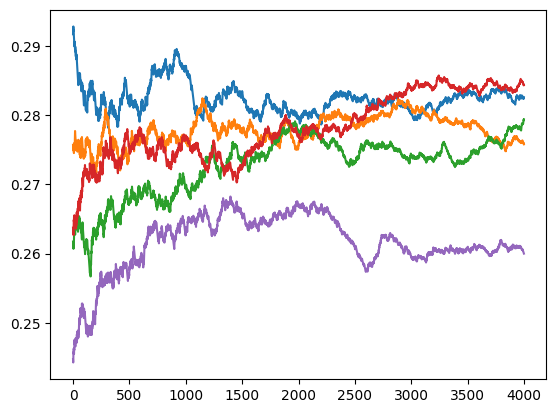

In [ ]:

def hypothesis_bias_against_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    mu_prior_mean,
    mu_prior_sigma,
    sigma_prior_alpha,
    sigma_prior_beta,
    cumulative=True,
    n_datasets=1000,
    n_marginal=1000,
):
    """
    Calculate the bias in favor a hypothesis using the sufficient statistic approach for the binomial-beta model.

    """

    mu0 = np.dot(X, beta0)

    # Dimensions
    p = X.shape[1]  # number of predictors
    num_samples = 5000  # number of samples

    # Priors
    # Sample beta from normal prior
    beta_samples = multivariate_normal.rvs(mean=beta0, cov=sigma0, size=5000) #norm.rvs(loc=beta0, scale=sigma0, size=(5000, p))

    # Sample sigma from inverse gamma prior
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=5000)

    # Likelihood (simulate data)
    y_samples = []
    prior_likelihoods = []


    for i in range(num_samples):
        beta = beta_samples[i]
        sigma = sigma_samples[i]
        mu = np.dot(X, beta)
        y_ = multivariate_normal.rvs(mean=mu, cov=(sigma) * np.eye(n_sample))
        prior_likelihood = multivariate_normal.logpdf(y_, mean=mu0, cov=(sigma0) * np.eye(n_sample))
        prior_likelihoods.append(prior_likelihood)
        y_samples.append(y_)

    y_samples = np.array(y_samples)



    prior_likelihoods = np.array(prior_likelihoods)
    print(prior_likelihoods[:10])
    y_samples = y_samples[:, :, np.newaxis]  # Shape (5000, n, 1)

    # Marginal likelihoods
    #marginal_likelihoods_raw = norm.logpdf(x= y_samples, loc = np.dot(X, beta_samples.T).T[:, :, np.newaxis], scale = sigma0)
    #marginal_likelihoods = marginal_likelihoods_raw.sum(axis=1)
    #log_marginal_likelihoods = np.log(np.exp(marginal_likelihoods).mean(axis=-1)).ravel()

    marginal_likelihoods_raw = np.zeros((num_samples, n_sample, 1))
    for i in range(num_samples):
        for j in range(n_sample):
            marginal_likelihoods_raw[i, j] = norm.logpdf(
                y_samples[i, j],
                loc=np.dot(X[j, :], beta_samples[i, :]),
                scale=sigma_samples[i]
            )

    # Sum over axis 1 to get marginal likelihoods
    marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)
    print(marginal_likelihoods[:10])
    # Compute log marginal likelihoods
    #log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()
    from scipy.special import logsumexp
    log_marginal_likelihoods = logsumexp(marginal_likelihoods, axis=-1) - np.log(n_marginal)

    # Bias against marginal likelihood
    bias_against_ml = (prior_likelihoods - log_marginal_likelihoods) <= 0

    # Compute the cumulative moving average for the bias
    bias_against_ml_mci = bias_against_ml.cumsum() / np.arange(1, len(bias_against_ml) + 1)

    # Plot the bias curve, ignoring the burn-in period
    burn = 1000

    if cumulative:
        return bias_against_ml_mci[burn:]
    else:
        return bias_against_ml_mci[-1]

import matplotlib.pyplot as plt
# Parameters
# Define prior parameters
mu_prior_mean = [2, 1]
mu_prior_sigma = 1
sigma_prior_alpha = 3
sigma_prior_beta = 2

n=10; p = 2
X = np.ones((n, p))
X[:int(n/2),0] = 0
X[0:-1:2,1] = 0

# Ground truth parameters
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1
mu0 = np.dot(X, beta0)

loops = 5
for i in range(loops):
    # Calculate bias against
    bias_against = hypothesis_bias_against_lin_reg(
        n,
        beta0,
        X,
        sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha = sigma_prior_alpha,
        sigma_prior_beta = sigma_prior_beta,
        cumulative = True,
        n_datasets=1000,
        n_marginal=1000
        )
    plt.plot(bias_against)

[5, 15, 25, 35, 45]


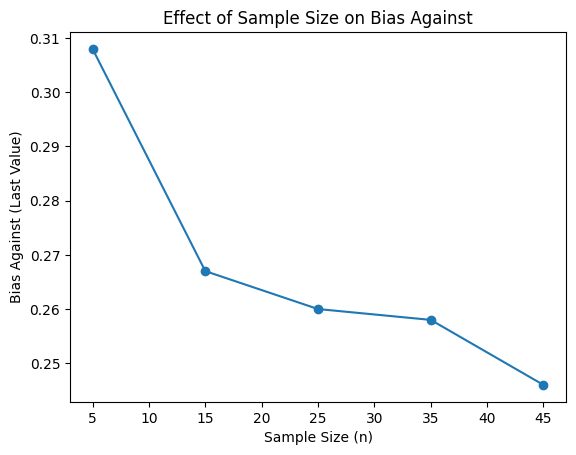

In [ ]:

# Parameters
mu_prior_mean = [2, 1]
mu_prior_sigma = 1
sigma_prior_alpha = 3
sigma_prior_beta = 2
p = 2
delta = 0.05
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Define n values
n_values = list(range(5, 50 + 1, 10))
bias_against_last_values = []
print(n_values)
for n in n_values:
    # Create X matrix with size (n, p)
    X = np.ones((n, p))
    X[:int(n/2), 0] = 0
    X[0:-1:2, 1] = 0
    bias_against_last = hypothesis_bias_against_lin_reg(
        n_sample=n,
        beta0=beta0,
        X=X,
        sigma0=sigma0,
        mu_prior_mean=mu_prior_mean,
        mu_prior_sigma=mu_prior_sigma,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        cumulative=False,
        n_datasets=1000
    )
    bias_against_last_values.append(bias_against_last)

# Plotting
plt.plot(n_values, bias_against_last_values, marker='o')
plt.xlabel("Sample Size (n)")
plt.ylabel("Bias Against (Last Value)")
plt.title("Effect of Sample Size on Bias Against")
plt.show()


0
1
2
3
4
5


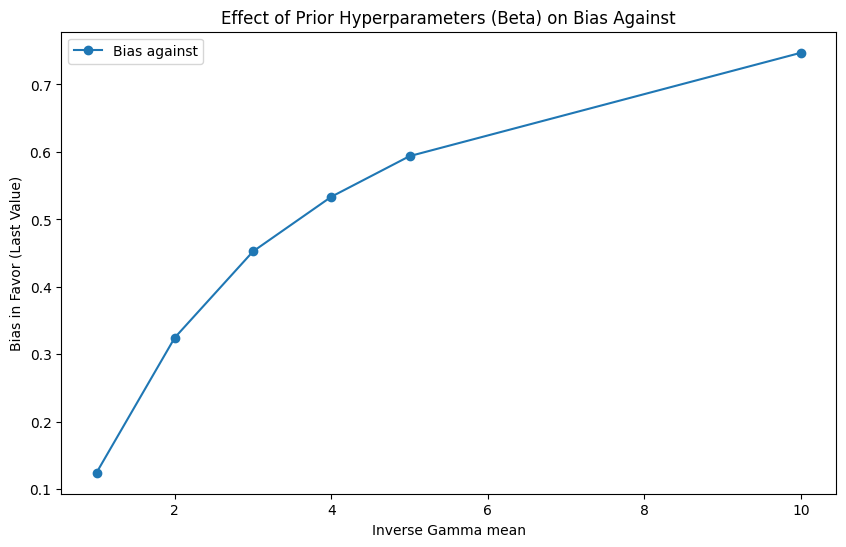

In [ ]:
import numpy as np
from scipy.stats import binom, beta
from scipy.special import logsumexp

def hypothesis_bias_against_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    sigma_prior_alpha,
    sigma_prior_beta,
    cumulative=True,
    n_datasets=1000,
    n_marginal=1000,
):
    """
    Calculate the bias in favor a hypothesis using the sufficient statistic approach for the binomial-beta model.

    """

    mu0 = np.dot(X, beta0)

    # Dimensions
    p = X.shape[1]  # number of predictors
    num_samples = 5000  # number of samples

    # Priors
    # Sample beta from normal prior
    beta_samples = norm.rvs(loc=beta0, scale=sigma0, size=(5000, p))

    # Sample sigma from inverse gamma prior
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=5000)

    # Likelihood (simulate data)
    y_samples = []
    prior_likelihoods = []


    for i in range(num_samples):
        beta = beta_samples[i]
        sigma = sigma_samples[i]
        mu = np.dot(X, beta)
        y_ = multivariate_normal.rvs(mean=mu, cov=(sigma0) * np.eye(n_sample))
        prior_likelihood = multivariate_normal.logpdf(y_, mean=mu0, cov=(sigma0) * np.eye(n_sample))
        prior_likelihoods.append(prior_likelihood)
        y_samples.append(y_)

    y_samples = np.array(y_samples)



    prior_likelihoods = np.array(prior_likelihoods)

    y_samples = y_samples[:, :, np.newaxis]  # Shape (5000, n, 1)

    # Marginal likelihoods
    #marginal_likelihoods_raw = norm.logpdf(x= y_samples, loc = np.dot(X, beta_samples.T).T[:, :, np.newaxis], scale = sigma0)
    #marginal_likelihoods = marginal_likelihoods_raw.sum(axis=1)
    #log_marginal_likelihoods = np.log(np.exp(marginal_likelihoods).mean(axis=-1)).ravel()

    marginal_likelihoods_raw = np.zeros((num_samples, n_sample, 1))
    for i in range(num_samples):
        for j in range(n_sample):
            marginal_likelihoods_raw[i, j] = norm.logpdf(
                y_samples[i, j],
                loc=np.dot(X[j, :], beta_samples[i, :]),
                scale=sigma_samples[i]
            )

    # Sum over axis 1 to get marginal likelihoods
    marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)

    # Compute log marginal likelihoods
    #log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()
    from scipy.special import logsumexp
    log_marginal_likelihoods = logsumexp(marginal_likelihoods, axis=-1) - np.log(n_marginal)

    # Bias against marginal likelihood
    bias_against_ml = (prior_likelihoods - log_marginal_likelihoods) <= 0

    # Compute the cumulative moving average for the bias
    bias_against_ml_mci = bias_against_ml.cumsum() / np.arange(1, len(bias_against_ml) + 1)

    # Plot the bias curve, ignoring the burn-in period
    burn = 1000

    if cumulative:
        return bias_against_ml_mci[burn:]
    else:
        return bias_against_ml_mci[-1]


# Parameters
biases = []

n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Experiment: Vary sigma_prior_alpha and sigma_prior_beta
alpha_values = [2, 2, 2, 2, 2, 2]
beta_values = [1, 2, 3, 4, 5, 10]

plt.figure(figsize=(10, 6))
for i in range(len(alpha_values)):
        print(i)
        sigma0 = beta_values[i]/(alpha_values[i] -1)
        bias_against = hypothesis_bias_against_lin_reg(
            n,
            beta0,
            X,
            sigma0,
            sigma_prior_alpha=alpha_values[i],
            sigma_prior_beta=beta_values[i],
            cumulative=False,
            n_datasets=1000
        )
        biases.append(bias_against)
plt.plot(beta_values, biases, label = "Bias against", marker = "o")
plt.xlabel('Inverse Gamma mean')
plt.ylabel('Bias in Favor (Last Value)')
plt.legend()
plt.title('Effect of Prior Hyperparameters (Beta) on Bias Against')
plt.show()


0
1
2
3
4
5


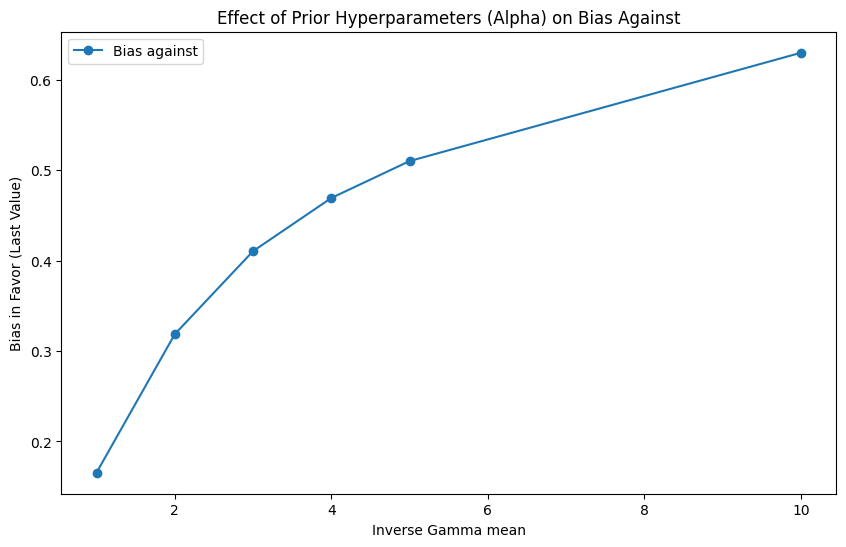

In [ ]:

# Parameters
biases = []

n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Experiment: Vary sigma_prior_alpha and sigma_prior_beta
beta_values = [2, 2, 2, 2, 2, 2]
alpha_values = [3, 2, 1.67, 1.5, 1.4, 1.2]

plt.figure(figsize=(10, 6))
for i in range(len(alpha_values)):
        print(i)
        sigma0 = beta_values[i]/(alpha_values[i] -1)

        bias_against = hypothesis_bias_against_lin_reg(
            n,
            beta0,
            X,
            sigma0,
            sigma_prior_alpha=alpha_values[i],
            sigma_prior_beta=beta_values[i],
            cumulative=False,
            n_datasets=1000
        )
        biases.append(bias_against)
plt.plot([1,2,3,4,5,10], biases, label = "Bias against", marker = "o")
plt.xlabel('Inverse Gamma mean')
plt.ylabel('Bias in Favor (Last Value)')
plt.legend()
plt.title('Effect of Prior Hyperparameters (Alpha) on Bias Against')
plt.show()


# Bias in favor

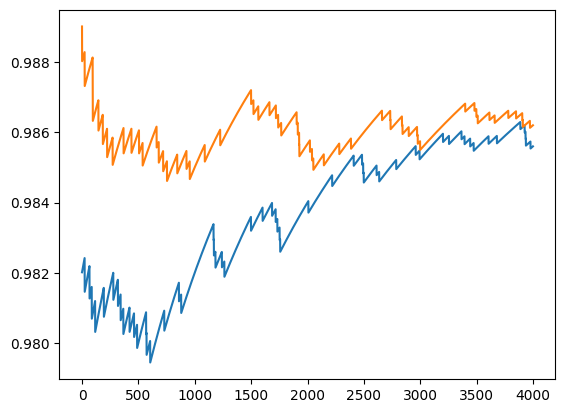

In [ ]:
import numpy as np
from scipy.stats import invgamma, multivariate_normal, norm
import matplotlib.pyplot as plt

def hypothesis_bias_in_favor_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    sigma_prior_alpha,
    sigma_prior_beta,
    delta=0.05,
    cumulative=True,
    n_datasets=1000
):
    # Number of data points and predictors
    n = X.shape[0]
    p = X.shape[1]
    num_samples = 5000  # number of samples

    # Adjust beta and mu bounds for hypothesis bias in favor
    betas = []
    # Priors
    # Sample beta from normal prior
    beta_samples = norm.rvs(loc=beta0, scale=mu_prior_sigma, size=(num_samples, p))

    # Sample sigma from inverse gamma prior
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=num_samples)
    biases_infav = []

    for i in range(p):
        for j in range(2):

            # Create a new beta value based on the current indices
            new_beta = beta0.copy()  # Copy the original beta0 to avoid modifying it directly
            new_beta[i] += (-1)**j * delta  # Modify the i-th element
            #new_beta[i] +  (-1)**j * delta  # Modify the i-th element
            betas.append(new_beta)  # Append the new value to the output list
            m_obs = np.dot(X, new_beta)
            mu0 = np.dot(X, beta0)


            # Initialize arrays for likelihoods
            #likelihoods_list = []
            y_samples = []
            likelihoods_ = []
            for k in range(num_samples):



              beta = beta_samples[k]
              sigma = sigma_samples[k]

              # Likelihood lower bound
              y_ = multivariate_normal.rvs(mean=m_obs, cov = sigma * np.eye(n))
              likelihood_ = multivariate_normal.logpdf(y_, mean = mu0, cov=sigma0 * np.eye(n))
              likelihoods_.append(likelihood_)
              y_samples.append(y_)

            y_samples = np.array(y_samples)


            marginal_likelihoods_raw = np.zeros((num_samples, n, 1))
            for k in range(num_samples):
                for t in range(n):
                    marginal_likelihoods_raw[k, t] = norm.logpdf(
                        y_samples[k, t],
                        loc=np.dot(X[t, :], beta_samples[k, :]),
                        scale=sigma_samples[k]
                    )

            # Sum over axis 1 to get marginal likelihoods
            marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)
            from scipy.special import logsumexp
            log_marginal_likelihoods = logsumexp(marginal_likelihoods, axis=-1) - np.log(num_samples)

            # Bias against marginal likelihood
            bias_infav_ml = (likelihoods_ - log_marginal_likelihoods) >= 0

            # Compute the cumulative moving average for the bias
            bias_infav_ml_mci = bias_infav_ml.cumsum() / np.arange(1, len(bias_infav_ml) + 1)
            biases_infav.append(bias_infav_ml_mci)


    # Compute cumulative moving average for the bias
    final_bias_cumsum = max(biases_infav, key=lambda x: x[-1])
    final_bias_cumsum_min = min(biases_infav, key=lambda x: x[-1])
    # Plot bias curve if desired
    burn = 1000
    if cumulative:
        return final_bias_cumsum[burn:]
    else:
        return final_bias_cumsum[-1]

# Parameters
# Define prior parameters
sigma_prior_alpha = 3
sigma_prior_beta = 2

n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0

# Ground truth parameters
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Run and plot
loops = 2
for i in range(loops):
    # Calculate bias in favor
    bias_in_favor = hypothesis_bias_in_favor_lin_reg(
        n,
        beta0,
        X,
        sigma0,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        delta=0.05,
        cumulative=True,
        n_datasets=1000
    )
    plt.plot(bias_in_favor)
plt.show()


In [ ]:
import numpy as np
from scipy.stats import invgamma, multivariate_normal, norm
import matplotlib.pyplot as plt

def hypothesis_bias_in_favor_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    sigma_prior_alpha,
    sigma_prior_beta,
    delta=0.05,
    cumulative=True,
    n_datasets=1000
):
    # Number of data points and predictors
    n = X.shape[0]
    p = X.shape[1]
    num_samples = 5000  # number of samples

    # Adjust beta and mu bounds for hypothesis bias in favor
    betas = []
    # Priors
    # Sample beta from normal prior
    beta_samples = norm.rvs(loc=beta0, scale=sigma0, size=(num_samples, p))

    # Sample sigma from inverse gamma prior
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=num_samples)
    biases_infav = []

    for i in range(p):
        for j in range(2):

            # Create a new beta value based on the current indices
            new_beta = beta0.copy()  # Copy the original beta0 to avoid modifying it directly
            new_beta[i] += (-1)**j * delta  # Modify the i-th element
            #new_beta[i] +  (-1)**j * delta  # Modify the i-th element
            betas.append(new_beta)  # Append the new value to the output list
            m_obs = np.dot(X, new_beta)
            mu0 = np.dot(X, beta0)


            # Initialize arrays for likelihoods
            #likelihoods_list = []
            y_samples = []
            likelihoods_ = []
            for k in range(num_samples):



              beta = beta_samples[k]
              sigma = sigma_samples[k]

              # Likelihood lower bound
              y_ = multivariate_normal.rvs(mean=m_obs, cov = sigma * np.eye(n))
              likelihood_ = multivariate_normal.logpdf(y_, mean = mu0, cov=sigma0 * np.eye(n))
              likelihoods_.append(likelihood_)
              y_samples.append(y_)

            y_samples = np.array(y_samples)


            marginal_likelihoods_raw = np.zeros((num_samples, n, 1))
            for k in range(num_samples):
                for t in range(n):
                    marginal_likelihoods_raw[k, t] = norm.logpdf(
                        y_samples[k, t],
                        loc=np.dot(X[t, :], beta_samples[k, :]),
                        scale=sigma_samples[k]
                    )

            # Sum over axis 1 to get marginal likelihoods
            marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)
            from scipy.special import logsumexp
            log_marginal_likelihoods = logsumexp(marginal_likelihoods, axis=-1) - np.log(num_samples)

            # Bias against marginal likelihood
            bias_infav_ml = (likelihoods_ - log_marginal_likelihoods) >= 0

            # Compute the cumulative moving average for the bias
            bias_infav_ml_mci = bias_infav_ml.cumsum() / np.arange(1, len(bias_infav_ml) + 1)
            biases_infav.append(bias_infav_ml_mci)


    # Compute cumulative moving average for the bias
    final_bias_cumsum = max(biases_infav, key=lambda x: x[-1])
    final_bias_cumsum_min = min(biases_infav, key=lambda x: x[-1])
    # Plot bias curve if desired
    burn = 1000
    if cumulative:
        return final_bias_cumsum[burn:]
    else:
        return final_bias_cumsum[-1]


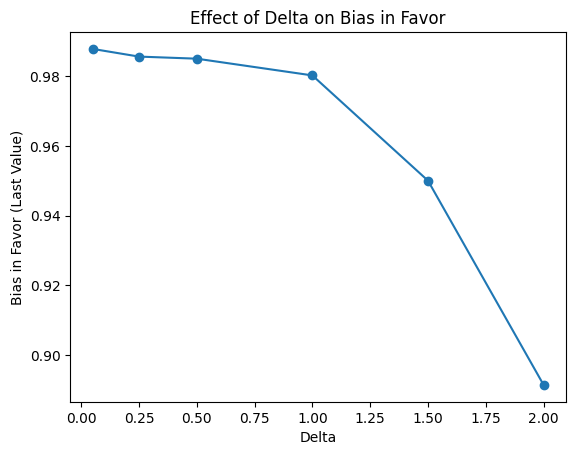

In [ ]:
# Parameters
mu_prior_mean = [2, 1]
mu_prior_sigma = 1
sigma_prior_alpha = 3
sigma_prior_beta = 2
n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Define delta values
delta_values = [0.05, 0.25, 0.50, 1, 1.5, 2]
bias_in_favor_last_values = []

for delta in delta_values:
    bias_in_favor_last = hypothesis_bias_in_favor_lin_reg(
        n_sample=n,
        beta0=beta0,
        X=X,
        sigma0=sigma0,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        delta=delta,
        cumulative=False,
        n_datasets=1000
    )
    bias_in_favor_last_values.append(bias_in_favor_last)

# Plotting
plt.plot(delta_values, bias_in_favor_last_values, marker='o')
plt.xlabel("Delta")
plt.ylabel("Bias in Favor (Last Value)")
plt.title("Effect of Delta on Bias in Favor")
plt.show()


[10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
10
20
30
40
50
60
70
80
90
100


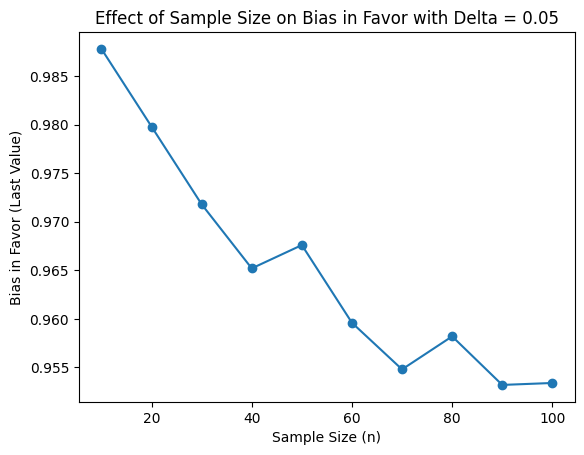

In [ ]:

# Parameters
sigma_prior_alpha = 3
sigma_prior_beta = 2
p = 2
delta = 0.05
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Define n values
n_values = list(range(10, 100 + 1, 10))
print(n_values)
bias_in_favor_last_values = []
for n in n_values:
    print(n)
    # Create X matrix with size (n, p)
    X = np.ones((n, p))
    X[:int(n/2), 0] = 0
    X[0:-1:2, 1] = 0
    bias_in_favor_last = hypothesis_bias_in_favor_lin_reg(
        n_sample=n,
        beta0=beta0,
        X=X,
        sigma0=sigma0,
        sigma_prior_alpha=sigma_prior_alpha,
        sigma_prior_beta=sigma_prior_beta,
        delta=delta,
        cumulative=False,
        n_datasets=1000
    )
    bias_in_favor_last_values.append(bias_in_favor_last)

# Plotting
plt.plot(n_values, bias_in_favor_last_values, marker='o')
plt.xlabel("Sample Size (n)")
plt.ylabel("Bias in Favor (Last Value)")
plt.title("Effect of Sample Size on Bias in Favor with Delta = 0.05")
plt.show()


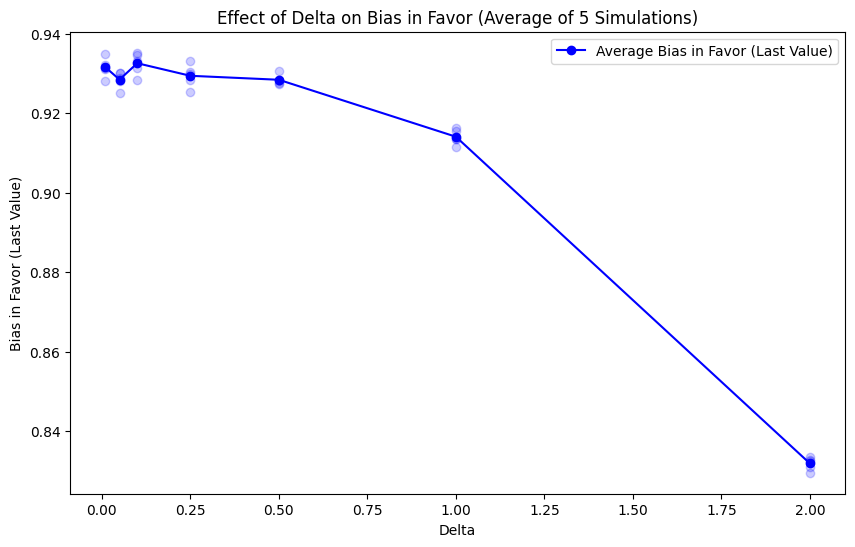

In [ ]:
# Parameters
mu_prior_mean = [2, 1]
mu_prior_sigma = 1
sigma_prior_alpha = 3
sigma_prior_beta = 2
n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Define delta values
delta_values = [0.01, 0.05, 0.10, 0.25, 0.50, 1, 2]
bias_in_favor_last_avg_values = []
all_bias_in_favor_last_values = []  # To store individual simulations for transparency

for delta in delta_values:
    # Run 5 simulations and collect results
    simulations = []
    for _ in range(5):
        bias_in_favor_last = hypothesis_bias_in_favor_lin_reg(
            n_sample=n,
            beta0=beta0,
            X=X,
            sigma0=sigma0,
            mu_prior_mean=mu_prior_mean,
            mu_prior_sigma=mu_prior_sigma,
            sigma_prior_alpha=sigma_prior_alpha,
            sigma_prior_beta=sigma_prior_beta,
            delta=delta,
            cumulative=False,
            n_datasets=1000
        )
        simulations.append(bias_in_favor_last)

    # Average of the 5 simulations for current delta
    avg_bias_in_favor_last = np.mean(simulations)
    bias_in_favor_last_avg_values.append(avg_bias_in_favor_last)
    all_bias_in_favor_last_values.append(simulations)  # Store for plotting transparency

# Plotting
plt.figure(figsize=(10, 6))

# Plot individual simulations with transparency
for i, delta in enumerate(delta_values):
    plt.scatter([delta] * 5, all_bias_in_favor_last_values[i], color='blue', alpha=0.2)

# Plot the average of the 5 simulations for each delta
plt.plot(delta_values, bias_in_favor_last_avg_values, marker='o', color='blue', label='Average Bias in Favor (Last Value)')
plt.xlabel("Delta")
plt.ylabel("Bias in Favor (Last Value)")
plt.title("Effect of Delta on Bias in Favor (Average of 5 Simulations)")
plt.legend()
plt.show()


### Changing the alpha hyperparameter

0
1


<ipython-input-28-e6fd1405c605>:53: RuntimeWarning: divide by zero encountered in log
  log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()


2
3
4
5


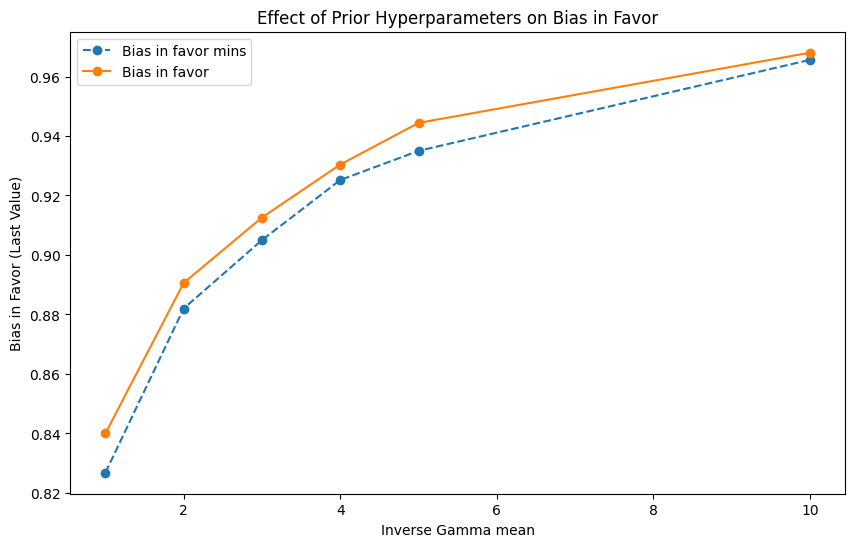

In [ ]:
import numpy as np
from scipy.stats import invgamma, multivariate_normal, norm
import matplotlib.pyplot as plt

def hypothesis_bias_in_favor_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    sigma_prior_alpha,
    sigma_prior_beta,
    delta=0.05,
    cumulative=True,
    n_datasets=1000
):
    n = X.shape[0]
    p = X.shape[1]
    num_samples = 5000  # number of samples

    betas = []
    beta_samples = norm.rvs(loc=beta0, scale=sigma0, size=(num_samples, p))
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=num_samples)
    biases_infav = []

    for i in range(p):
        for j in range(2):
            new_beta = beta0.copy()
            new_beta[i] += (-1)**j * delta
            betas.append(new_beta)
            m_obs = np.dot(X, new_beta)
            mu0 = np.dot(X, beta0)

            y_samples = []
            likelihoods_ = []
            for k in range(num_samples):
                beta = beta_samples[k]
                sigma = sigma_samples[k]
                y_ = multivariate_normal.rvs(mean=m_obs, cov = sigma * np.eye(n))
                likelihood_ = multivariate_normal.logpdf(y_, mean = mu0, cov=sigma0 * np.eye(n))
                likelihoods_.append(likelihood_)
                y_samples.append(y_)

            y_samples = np.array(y_samples)
            marginal_likelihoods_raw = np.zeros((num_samples, n, 1))
            for k in range(num_samples):
                for t in range(n):
                    marginal_likelihoods_raw[k, t] = norm.logpdf(
                        y_samples[k, t],
                        loc=np.dot(X[t, :], beta_samples[k, :]),
                        scale=sigma_samples[k]
                    )
            marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)
            log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()
            bias_infav_ml = (likelihoods_ - log_marginal_likelihoods) >= 0
            bias_infav_ml_mci = bias_infav_ml.cumsum() / np.arange(1, len(bias_infav_ml) + 1)
            biases_infav.append(bias_infav_ml_mci)

    final_bias_cumsum = max(biases_infav, key=lambda x: x[-1])
    final_bias_cumsum_min = min(biases_infav, key=lambda x: x[-1])
    burn = 1000
    if cumulative:
        return [final_bias_cumsum[burn:], final_bias_cumsum_min[burn:]]
    else:
        return [final_bias_cumsum[-1], final_bias_cumsum_min[-1]]

# Parameters
mins = []
maxs = []

n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Experiment: Vary sigma_prior_alpha and sigma_prior_beta
beta_values = [2, 2, 2, 2, 2,2 ]
alpha_values = [3, 2, 1.67, 1.5, 1.4, 1.2]
plt.figure(figsize=(10, 6))
for i in range(len(alpha_values)):
        print(i)
        sigma0 = beta_values[i]/(alpha_values[i] - 1)
        bias_in_favor = hypothesis_bias_in_favor_lin_reg(
            n,
            beta0,
            X,
            sigma0,
            sigma_prior_alpha=alpha_values[i],
            sigma_prior_beta=beta_values[i],
            delta=0.05,
            cumulative=False,
            n_datasets=1000
        )
        maxs.append(bias_in_favor[0])
        mins.append(bias_in_favor[1])
plt.plot([1, 2, 3, 4, 5, 10] , mins, linestyle = "--", label = "Bias in favor mins", marker='o')
plt.plot([1, 2, 3, 4, 5, 10] , maxs, label = "Bias in favor", marker='o')
plt.xlabel('Inverse Gamma mean')
plt.ylabel('Bias in Favor (Last Value)')
plt.legend()
plt.title('Effect of Prior Hyperparameters on Bias in Favor')
plt.show()


### Changing the beta hyperparameter

0


<ipython-input-30-8de1be8376f0>:53: RuntimeWarning: divide by zero encountered in log
  log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()


1
2
3
4
5


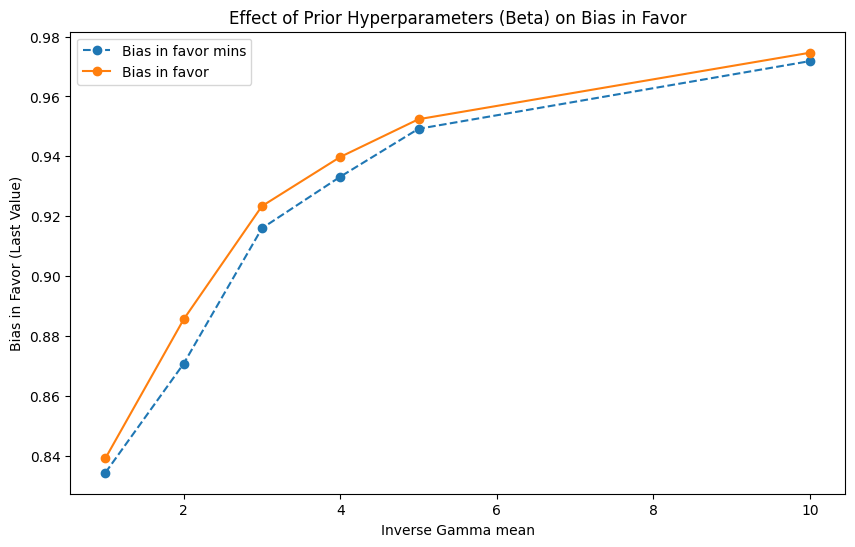

In [ ]:
import numpy as np
from scipy.stats import invgamma, multivariate_normal, norm
import matplotlib.pyplot as plt

def hypothesis_bias_in_favor_lin_reg(
    n_sample,
    beta0,
    X,
    sigma0,
    sigma_prior_alpha,
    sigma_prior_beta,
    delta=0.05,
    cumulative=True,
    n_datasets=1000
):
    n = X.shape[0]
    p = X.shape[1]
    num_samples = 5000  # number of samples

    betas = []
    beta_samples = norm.rvs(loc=beta0, scale=sigma0, size=(num_samples, p))
    sigma_samples = invgamma.rvs(a=sigma_prior_alpha, scale=sigma_prior_beta, size=num_samples)
    biases_infav = []

    for i in range(p):
        for j in range(2):
            new_beta = beta0.copy()
            new_beta[i] += (-1)**j * delta
            betas.append(new_beta)
            m_obs = np.dot(X, new_beta)
            mu0 = np.dot(X, beta0)

            y_samples = []
            likelihoods_ = []
            for k in range(num_samples):
                beta = beta_samples[k]
                sigma = sigma_samples[k]
                y_ = multivariate_normal.rvs(mean=m_obs, cov = sigma * np.eye(n))
                likelihood_ = multivariate_normal.logpdf(y_, mean = mu0, cov=sigma0 * np.eye(n))
                likelihoods_.append(likelihood_)
                y_samples.append(y_)

            y_samples = np.array(y_samples)
            marginal_likelihoods_raw = np.zeros((num_samples, n, 1))
            for k in range(num_samples):
                for t in range(n):
                    marginal_likelihoods_raw[k, t] = norm.logpdf(
                        y_samples[k, t],
                        loc=np.dot(X[t, :], beta_samples[k, :]),
                        scale=sigma_samples[k]
                    )
            marginal_likelihoods = np.sum(marginal_likelihoods_raw, axis=1)
            log_marginal_likelihoods = np.log(np.mean(np.exp(marginal_likelihoods[:, np.newaxis]), axis=-1)).ravel()
            bias_infav_ml = (likelihoods_ - log_marginal_likelihoods) >= 0
            bias_infav_ml_mci = bias_infav_ml.cumsum() / np.arange(1, len(bias_infav_ml) + 1)
            biases_infav.append(bias_infav_ml_mci)

    final_bias_cumsum = max(biases_infav, key=lambda x: x[-1])
    final_bias_cumsum_min = min(biases_infav, key=lambda x: x[-1])
    burn = 1000
    if cumulative:
        return [final_bias_cumsum[burn:], final_bias_cumsum_min[burn:]]
    else:
        return [final_bias_cumsum[-1], final_bias_cumsum_min[-1]]

# Parameters
mins = []
maxs = []

n = 10
p = 2
X = np.ones((n, p))
X[:int(n/2), 0] = 0
X[0:-1:2, 1] = 0
beta0 = np.logspace(0, 1, 2, base=2)
sigma0 = 1

# Experiment: Vary sigma_prior_alpha and sigma_prior_beta
alpha_values = [2, 2, 2, 2, 2, 2]
beta_values = [1, 2, 3, 4, 5, 10]

plt.figure(figsize=(10, 6))
for i in range(len(alpha_values)):
        print(i)
        sigma0 = beta_values[i]/(alpha_values[i] - 1)
        bias_in_favor = hypothesis_bias_in_favor_lin_reg(
            n,
            beta0,
            X,
            sigma0,
            sigma_prior_alpha=alpha_values[i],
            sigma_prior_beta=beta_values[i],
            delta=0.05,
            cumulative=False,
            n_datasets=1000
        )
        maxs.append(bias_in_favor[0])
        mins.append(bias_in_favor[1])
plt.plot(beta_values, mins, linestyle = "--", label = "Bias in favor mins", marker = "o")
plt.plot(beta_values, maxs, label = "Bias in favor", marker = "o")
plt.xlabel('Inverse Gamma mean')
plt.ylabel('Bias in Favor (Last Value)')
plt.legend()
plt.title('Effect of Prior Hyperparameters (Beta) on Bias in Favor')
plt.show()
